# SMAP Calibration Date Rainfall Filter (GPM IMERG)

This notebook acts as a **post-filter** on the per-class SMAP calibration dates produced by
`SPL3SMP_E_calib_dates_per_class.ipynb`.

**Logic:**  
For every `flag = 1` date in each class CSV, the corresponding GPM IMERG daily precipitation
is checked at the GPM grid cell **nearest** (by Euclidean lat/lon distance) to each SMAP
station belonging to that class.  
A date is **accepted** if ≥ `STATION_COVERAGE_THRESHOLD` (75 %) of the class stations
receive rainfall ≥ `RAINFALL_THRESHOLD_MM` (5 mm) from GPM.  
For accepted dates a symmetric ±`DATE_WINDOW` (2) day window is stored to a **new** CSV.  
The original calibration CSVs are never modified.

| Column | Meaning |
|--------|---------|
| `event_date` | The flag = 1 date that passed the rainfall filter |
| `date` | Calendar date in the ±window written to file |
| `offset_days` | Distance from the event date (−2 … +2) |
| `flag` | 1 = the event date itself, 0 = window day |


## 1 · Import Libraries

In [13]:
import numpy as np
import pandas as pd
import netCDF4 as nc
from scipy.spatial import cKDTree
from pathlib import Path
from datetime import timedelta
import warnings
import os
import glob
from datetime import datetime as _dt, timedelta as _td



warnings.filterwarnings('ignore')
# os.chdir('/master_storage6/ishan/my_data/SSM-irrigation-data/SMAP')

print('Libraries imported successfully.')


Libraries imported successfully.


## 2 · Configuration

In [14]:
# ── Rainfall threshold ────────────────────────────────────────────────────────
RAINFALL_THRESHOLD_MM      = 4.0    # mm/day
STATION_COVERAGE_THRESHOLD = 0.60   # 75 %

# ── Window / check-mode settings ─────────────────────────────────────────────
USE_WINDOW_CHECK = True   # True  → accept if ANY day in [-DAYS_BEFORE … +DAYS_AFTER] passes
                          # False → check only the exact flag=1 day
DAYS_BEFORE      = 2      # days before the flag=1 date to include in the check window
DAYS_AFTER       = 2      # days after  the flag=1 date to include in the check window
                          # (DAYS_BEFORE / DAYS_AFTER are only used when USE_WINDOW_CHECK=True)

# ── Input paths ───────────────────────────────────────────────────────────────
CALIB_DIR   = Path(r'G:\SM2RAIN-irrigation_Final\calibration\calib_dates_ludhiana')          # ← original CSVs (read-only)
SMAP_NC_FILE  = Path(r'G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc')
GPM_NC_FILE = Path(r'G:\SM2RAIN-irrigation_Final\data\precipitation_data\GPM_IMERG_ludhiana_final_run.nc')
CLASS_CSV   = Path(r'G:\SM2RAIN-irrigation_Final\calibration\GPM_classes_ludhiana\rainfall_classification_5_bins_GMM.csv.')

# ── Output directory (new CSVs go here, originals untouched) ─────────────────
OUTPUT_DIR  = Path('calib_dates_rainfall_filtered')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_check_mode_str = (
    f'Window (-{DAYS_BEFORE}/+{DAYS_AFTER} days) – any day passes'
    if USE_WINDOW_CHECK else 'Flag=1 day only'
)
print('Configuration:')
print(f'  Rainfall threshold       : {RAINFALL_THRESHOLD_MM} mm/day')
print(f'  Station coverage required: {STATION_COVERAGE_THRESHOLD:.0%}')
print(f'  Check mode               : {_check_mode_str}')
print(f'  Calib CSVs directory     : {CALIB_DIR}')
print(f'  GPM IMERG file           : {GPM_NC_FILE}')
print(f'  Class CSV                : {CLASS_CSV}')
print(f'  Output directory         : {OUTPUT_DIR}')


Configuration:
  Rainfall threshold       : 4.0 mm/day
  Station coverage required: 60%
  Check mode               : Window (-2/+2 days) – any day passes
  Calib CSVs directory     : G:\SM2RAIN-irrigation_Final\calibration\calib_dates_ludhiana
  GPM IMERG file           : G:\SM2RAIN-irrigation_Final\data\precipitation_data\GPM_IMERG_ludhiana_final_run.nc
  Class CSV                : G:\SM2RAIN-irrigation_Final\calibration\GPM_classes_ludhiana\rainfall_classification_5_bins_GMM.csv.
  Output directory         : calib_dates_rainfall_filtered


## 3 · Load SMAP Calibration Dates Per Class

In [15]:
# Discover all per-class CSV files (class_1 … class_5)
csv_files = sorted(CALIB_DIR.glob('class_*_calib_dates.csv'))
if not csv_files:
    raise FileNotFoundError(f'No class CSVs found in {CALIB_DIR}')

# calib_flag1[class_int] = list of pd.Timestamp for flag=1 dates
# calib_all[class_int]   = full DataFrame (date, flag) as-loaded
calib_flag1 = {}
calib_all   = {}

for fp in csv_files:
    cls = int(fp.stem.split('_')[1])          # extract class number from filename
    df  = pd.read_csv(fp, parse_dates=['date'])
    calib_all[cls]   = df.copy()
    flag1_dates      = df.loc[df['flag'] == 1, 'date'].tolist()
    calib_flag1[cls] = sorted(flag1_dates)
    print(f'  Class {cls}: {len(df)} total rows | {len(flag1_dates)} flag=1 dates')

classes = sorted(calib_flag1.keys())
print(f'\nClasses found: {classes}')


  Class 1: 1085 total rows | 257 flag=1 dates
  Class 2: 1168 total rows | 272 flag=1 dates
  Class 3: 1151 total rows | 275 flag=1 dates
  Class 4: 1095 total rows | 259 flag=1 dates
  Class 5: 1032 total rows | 238 flag=1 dates

Classes found: [1, 2, 3, 4, 5]


## 4 · Load GPM IMERG NetCDF

In [16]:
if not GPM_NC_FILE.exists():
    raise FileNotFoundError(f'GPM IMERG file not found: {GPM_NC_FILE}')

print(f'Opening: {GPM_NC_FILE}')
gpm_ds = nc.Dataset(GPM_NC_FILE, 'r')

# ── Coordinates ───────────────────────────────────────────────────────────────
gpm_lat = gpm_ds.variables['lat'][:]          # shape (n_lat,)
gpm_lon = gpm_ds.variables['lon'][:]          # shape (n_lon,)

# ── Precipitation: stored as (time, lon, lat) in this file ───────────────────
# We load it directly; indexing later: precip[t_idx, lon_idx, lat_idx]
gpm_precip = gpm_ds.variables['precipitation'][:]   # (n_time, n_lon, n_lat)

# ── Date strings (DD-MM-YYYY) → pandas DatetimeIndex ─────────────────────────
raw_dates  = nc.chartostring(gpm_ds.variables['date'][:])   # numpy array of strings
gpm_dates  = pd.to_datetime(raw_dates, format='%d-%m-%Y')   # DatetimeIndex

gpm_ds.close()

# Build a fast date → time-dimension-index lookup
gpm_date_index = {d.date(): i for i, d in enumerate(gpm_dates)}

print(f'GPM lat range : {gpm_lat.min():.2f} → {gpm_lat.max():.2f}  ({len(gpm_lat)} points)')
print(f'GPM lon range : {gpm_lon.min():.2f} → {gpm_lon.max():.2f}  ({len(gpm_lon)} points)')
print(f'GPM date range: {gpm_dates.min().date()}  →  {gpm_dates.max().date()}  ({len(gpm_dates)} days)')
print(f'Precip shape  : {gpm_precip.shape}  (time × lon × lat)')


Opening: G:\SM2RAIN-irrigation_Final\data\precipitation_data\GPM_IMERG_ludhiana_final_run.nc
GPM lat range : 29.95 → 31.05  (12 points)
GPM lon range : 74.95 → 76.05  (12 points)
GPM date range: 2015-01-01  →  2025-12-31  (4018 days)
Precip shape  : (4018, 12, 12)  (time × lon × lat)


## 5 · Load Rainfall Classification CSV (SMAP Station→Class Map)

In [17]:
class_df = pd.read_csv(CLASS_CSV)

# Normalise column names (lower-case, strip whitespace)
class_df.columns = class_df.columns.str.strip().str.lower()

# Accept either 'bin' or 'rainfall_class' as the class column
if 'bin' in class_df.columns:
    class_df = class_df.rename(columns={'bin': 'rainfall_class'})

print(f'Station CSV shape : {class_df.shape}')
print(f'Columns           : {list(class_df.columns)}')
print(f'Class distribution:')
print(class_df['rainfall_class'].value_counts().sort_index().to_string())

# Per-class station coordinate arrays: {class_int: np.array shape (n,2) [lat, lon]}
class_coords = {}
for cls in classes:
    subset = class_df[class_df['rainfall_class'] == cls][['latitude', 'longitude']]
    class_coords[cls] = subset.values          # (n_stations, 2)
    print(f'  Class {cls}: {len(subset)} station(s)')


Station CSV shape : (144, 5)
Columns           : ['latitude', 'longitude', 'annual_avg_rainfall_mm', 'rainfall_class', 'grid_cell_index']
Class distribution:
rainfall_class
1    26
2    13
3    39
4    37
5    29
  Class 1: 26 station(s)
  Class 2: 13 station(s)
  Class 3: 39 station(s)
  Class 4: 37 station(s)
  Class 5: 29 station(s)


## 6 · Nearest-Neighbour Matching: SMAP Stations → GPM Grid Cells

Each SMAP station point (from the classification CSV) is matched to its nearest GPM
grid cell using a **cKDTree** built from the flattened GPM (lat, lon) mesh.

The precipitation array has shape `(time, lon_idx, lat_idx)`.  Each matched station
stores `(lon_idx, lat_idx)` so daily precip can be extracted as `gpm_precip[t, lon_i, lat_i]`.


In [18]:
# ── Build KDTree over the full GPM 2-D grid ───────────────────────────────────
# GPM precipitation dims are (time, lon_idx, lat_idx), so we need
# (lon_idx, lat_idx) as the index pair, not (lat_idx, lon_idx).
gpm_lon_grid, gpm_lat_grid = np.meshgrid(gpm_lon, gpm_lat, indexing='ij')
# gpm_lon_grid shape: (n_lon, n_lat)  — matches precip's lon/lat axes

# Flatten to (N, 2) array of [lat, lon] for distance query in geographic coords
gpm_pts = np.column_stack([gpm_lat_grid.ravel(), gpm_lon_grid.ravel()])
gpm_tree = cKDTree(gpm_pts)

n_lon = len(gpm_lon)
n_lat = len(gpm_lat)

def smap_to_gpm_indices(smap_latlon_array):
    """
    Given an (n_stations, 2) array of [lat, lon] for SMAP stations,
    return list of (lon_idx, lat_idx) tuples for indexing gpm_precip.

    Uses nearest-neighbour (Euclidean distance in degrees) via cKDTree.
    This is valid for small ROIs where degree-based distance is acceptable.
    """
    _, flat_idx = gpm_tree.query(smap_latlon_array)   # flat index into meshgrid
    lon_idx = flat_idx // n_lat   # meshgrid was built with indexing='ij'
    lat_idx = flat_idx  % n_lat
    return list(zip(lon_idx.tolist(), lat_idx.tolist()))

# Pre-compute per-class GPM index lists
class_gpm_indices = {}
for cls in classes:
    coords = class_coords[cls]                  # (n_stations, 2) [lat, lon]
    idx_list = smap_to_gpm_indices(coords)
    class_gpm_indices[cls] = idx_list
    # Show matched GPM cells for verification
    matched_gpm = [(float(gpm_lat[li]), float(gpm_lon[oi])) for oi, li in idx_list]
    print(f'  Class {cls}: {len(idx_list)} SMAP stations → GPM cells: '
          f'{sorted(set(matched_gpm))[:4]}{"…" if len(set(matched_gpm)) > 4 else ""}')

print('\nNearest-neighbour mapping complete.')


  Class 1: 26 SMAP stations → GPM cells: [(29.950000762939453, 74.94999694824219), (29.950000762939453, 75.05000305175781), (29.950000762939453, 75.1500015258789), (29.950000762939453, 75.25)]…
  Class 2: 13 SMAP stations → GPM cells: [(29.950000762939453, 75.44999694824219), (30.049999237060547, 75.44999694824219), (30.149999618530273, 75.3499984741211), (30.149999618530273, 75.44999694824219)]…
  Class 3: 39 SMAP stations → GPM cells: [(29.950000762939453, 75.55000305175781), (29.950000762939453, 75.6500015258789), (29.950000762939453, 75.75), (29.950000762939453, 75.8499984741211)]…
  Class 4: 37 SMAP stations → GPM cells: [(30.549999237060547, 74.94999694824219), (30.549999237060547, 75.1500015258789), (30.549999237060547, 75.25), (30.549999237060547, 75.3499984741211)]…
  Class 5: 29 SMAP stations → GPM cells: [(30.450000762939453, 76.05000305175781), (30.549999237060547, 75.8499984741211), (30.549999237060547, 75.94999694824219), (30.549999237060547, 76.05000305175781)]…

Nearest


## 7 · Rainfall Filter with Cluster-Aware Window Check

For each class the `flag = 1` dates are first **grouped into clusters** where consecutive dates are
**< 4 days apart** — such dates likely belong to the same irrigation/rainfall event and are evaluated
together rather than independently.

For each cluster:

1. **Build the check window**: from `cluster_first − DAYS_BEFORE` to `cluster_last + DAYS_AFTER`  
   (when `USE_WINDOW_CHECK = True`; otherwise only the cluster's own flag=1 dates are checked).
2. **Scan every day** in the window against GPM IMERG precipitation.
3. **Accept** the whole cluster as soon as any single day satisfies  
   `fraction of stations with precip ≥ RAINFALL_THRESHOLD_MM ≥ STATION_COVERAGE_THRESHOLD`.
4. **Reject** if no day in the window passes; **skip** (no-GPM) if every day is absent from the archive.

**Output window**: accepted clusters are expanded to `[first − DAYS_BEFORE … last + DAYS_AFTER]`;  
original `flag = 1` dates within the cluster keep `flag = 1`, all surrounding window days get `flag = 0`.

> Merging close dates prevents the same rainfall event being counted multiple times and avoids
> independent accept/reject decisions for nearly-simultaneous SM rises.


In [19]:

def _cluster_dates(dates, min_gap=4):
    """
    Group sorted Timestamps into clusters.
    Two consecutive dates belong to the same cluster when their gap < min_gap days.
    Returns a list of lists, each sub-list containing the cluster's Timestamps.
    """
    if not dates:
        return []
    sorted_d = sorted(pd.Timestamp(d) for d in dates)
    clusters = [[sorted_d[0]]]
    for d in sorted_d[1:]:
        if (d - clusters[-1][-1]).days < min_gap:
            clusters[-1].append(d)
        else:
            clusters.append([d])
    return clusters


filtered_results = {}   # class → dict with rows, accepted_events, rejected_dates

print('Running rainfall filter...')
print(f'  Threshold  : {RAINFALL_THRESHOLD_MM} mm/day')
print(f'  Coverage   : {STATION_COVERAGE_THRESHOLD:.0%} of stations per class')
print(f'  Cluster gap: < 4 days → merged into one event')
if USE_WINDOW_CHECK:
    print(f'  Check mode : window (-{DAYS_BEFORE}/+{DAYS_AFTER} days around cluster bounds) '
          f'– accept if ANY day passes\n')
else:
    print(f'  Check mode : flag=1 days only (no window expansion)\n')

for cls in classes:
    flag1_dates  = calib_flag1[cls]
    gpm_idx_list = class_gpm_indices[cls]   # [(lon_i, lat_i), …] one per station
    n_stations   = len(gpm_idx_list)

    accepted_events   = []   # flat list of pd.Timestamp (all flag=1 dates that were accepted)
    rejected_dates    = []   # flat list of pd.Timestamp (rejected flag=1 dates)
    missing_gpm_dates = []   # flag=1 dates where ALL checked days absent from GPM

    # ── Group flag=1 dates into clusters (gap < 4 days → same event) ──────────
    clusters = _cluster_dates(flag1_dates, min_gap=4)

    for cluster in clusters:
        first_ev = cluster[0]
        last_ev  = cluster[-1]

        # ── Build the day list to check against GPM ───────────────────────────
        if USE_WINDOW_CHECK:
            # Span from first_ev – DAYS_BEFORE to last_ev + DAYS_AFTER
            check_start = first_ev - pd.Timedelta(days=DAYS_BEFORE)
            check_end   = last_ev  + pd.Timedelta(days=DAYS_AFTER)
            window_days = [
                check_start + pd.Timedelta(days=i)
                for i in range((check_end - check_start).days + 1)
            ]
        else:
            # Only check the actual flag=1 dates in this cluster
            window_days = list(cluster)

        any_pass    = False   # True once at least one checked day passes
        all_missing = True    # False once at least one checked day has GPM data

        for wd in window_days:
            t_idx = gpm_date_index.get(wd.date())
            if t_idx is None:
                continue          # this calendar day absent from GPM archive
            all_missing = False

            station_precip = np.array([
                float(gpm_precip[t_idx, lon_i, lat_i])
                for lon_i, lat_i in gpm_idx_list
            ])
            frac_above = float(np.sum(station_precip >= RAINFALL_THRESHOLD_MM)) / n_stations

            if frac_above >= STATION_COVERAGE_THRESHOLD:
                any_pass = True
                break   # no need to check further days in this cluster's window

        if all_missing:
            missing_gpm_dates.extend(cluster)
        elif any_pass:
            accepted_events.extend(cluster)   # all flag=1 dates in cluster accepted
        else:
            rejected_dates.extend(cluster)    # all flag=1 dates in cluster rejected

    # ── Expand accepted events into output rows ───────────────────────────────
    # Re-cluster accepted events (they keep the same cluster structure) to build
    # a contiguous date window per cluster:
    #   flag = 1 for original flag=1 dates, flag = 0 for the surrounding window days.
    rows = []
    seen_dates = set()
    if accepted_events:
        accepted_clusters = _cluster_dates(accepted_events, min_gap=4)
        for clust in accepted_clusters:
            clust_flag1_set = set(clust)           # original event dates → flag=1
            event_date_label = clust[0]            # first date in cluster as event_date
            out_start = clust[0]  - pd.Timedelta(days=DAYS_BEFORE)
            out_end   = clust[-1] + pd.Timedelta(days=DAYS_AFTER)

            d = out_start
            while d <= out_end:
                if d not in seen_dates:
                    seen_dates.add(d)
                    rows.append({
                        'event_date' : event_date_label,
                        'date'       : d,
                        'offset_days': (d - event_date_label).days,
                        'flag'       : 1 if d in clust_flag1_set else 0,
                    })
                d += pd.Timedelta(days=1)

    filtered_results[cls] = {
        'rows'             : rows,
        'accepted_events'  : accepted_events,
        'rejected_dates'   : rejected_dates,
        'missing_gpm_dates': missing_gpm_dates,
        'clusters_total'   : len(clusters),
    }

    n_clusters_accepted = len(_cluster_dates(accepted_events, min_gap=4))
    n_clusters_rejected = len(_cluster_dates(rejected_dates,  min_gap=4))
    print(f'  Class {cls}  |  {n_stations} stns  |  '
          f'{len(flag1_dates)} flag=1 dates in {len(clusters)} clusters  |  '
          f'{len(accepted_events)} dates ({n_clusters_accepted} clusters) accepted  |  '
          f'{len(rejected_dates)} dates ({n_clusters_rejected} clusters) rejected  |  '
          f'{len(missing_gpm_dates)} no-GPM  |  '
          f'{len(rows)} rows to write')

print('\nFiltering complete.')


Running rainfall filter...
  Threshold  : 4.0 mm/day
  Coverage   : 60% of stations per class
  Cluster gap: < 4 days → merged into one event
  Check mode : window (-2/+2 days around cluster bounds) – accept if ANY day passes

  Class 1  |  26 stns  |  257 flag=1 dates in 200 clusters  |  106 dates (81 clusters) accepted  |  151 dates (119 clusters) rejected  |  0 no-GPM  |  463 rows to write
  Class 2  |  13 stns  |  272 flag=1 dates in 219 clusters  |  104 dates (78 clusters) accepted  |  168 dates (141 clusters) rejected  |  0 no-GPM  |  451 rows to write
  Class 3  |  39 stns  |  275 flag=1 dates in 214 clusters  |  122 dates (82 clusters) accepted  |  153 dates (132 clusters) rejected  |  0 no-GPM  |  501 rows to write
  Class 4  |  37 stns  |  259 flag=1 dates in 202 clusters  |  104 dates (76 clusters) accepted  |  155 dates (126 clusters) rejected  |  0 no-GPM  |  446 rows to write
  Class 5  |  29 stns  |  238 flag=1 dates in 196 clusters  |  118 dates (95 clusters) accepted  

## 8 · Save Filtered Dates to New CSV Files Per Class

Output goes to `smap_rainfall_filtered_dates/class_<N>_filtered_dates.csv`.  
**Original files in `smap_calib_dates_per_class/` are never touched.**

Columns written:

| Column | Description |
|--------|-------------|
| `event_date` | The flag=1 date that passed the GPM rainfall filter |
| `date` | The actual date being written (event ± window offset) |
| `offset_days` | Signed offset from the event date (−2 … +2) |
| `flag` | 1 for the event date, 0 for window days |


In [20]:
print('Saving filtered CSVs...\n')

for cls in classes:
    rows = filtered_results[cls]['rows']

    if not rows:
        print(f'  Class {cls}: no accepted dates — CSV not written.')
        continue

    out_df = pd.DataFrame(rows)
    out_df['event_date'] = pd.to_datetime(out_df['event_date']).dt.strftime('%Y-%m-%d')
    out_df['date']       = pd.to_datetime(out_df['date']).dt.strftime('%Y-%m-%d')

    out_path = OUTPUT_DIR / f'class_{cls}_filtered_dates.csv'
    out_df.to_csv(out_path, index=False)

    n_events   = out_df[out_df['flag'] == 1].shape[0]
    n_window   = out_df[out_df['flag'] == 0].shape[0]
    date_range = f'{out_df["date"].min()} → {out_df["date"].max()}'
    print(f'  Class {cls}: {n_events} event dates (flag=1) | '
          f'{n_window} window dates (flag=0) | '
          f'{len(out_df)} total rows | '
          f'date range: {date_range}')
    print(f'    → {out_path}')

print(f'\nAll CSVs saved to: {OUTPUT_DIR}')
print('\n⚠  Original files in smap_calib_dates_per_class/ were NOT modified.')


Saving filtered CSVs...

  Class 1: 106 event dates (flag=1) | 357 window dates (flag=0) | 463 total rows | date range: 2015-04-06 → 2025-10-07
    → calib_dates_rainfall_filtered\class_1_filtered_dates.csv
  Class 2: 104 event dates (flag=1) | 347 window dates (flag=0) | 451 total rows | date range: 2015-04-06 → 2025-10-07
    → calib_dates_rainfall_filtered\class_2_filtered_dates.csv
  Class 3: 122 event dates (flag=1) | 379 window dates (flag=0) | 501 total rows | date range: 2015-04-14 → 2025-09-05
    → calib_dates_rainfall_filtered\class_3_filtered_dates.csv
  Class 4: 104 event dates (flag=1) | 342 window dates (flag=0) | 446 total rows | date range: 2015-04-06 → 2025-10-07
    → calib_dates_rainfall_filtered\class_4_filtered_dates.csv
  Class 5: 118 event dates (flag=1) | 412 window dates (flag=0) | 530 total rows | date range: 2015-04-06 → 2025-10-07
    → calib_dates_rainfall_filtered\class_5_filtered_dates.csv

All CSVs saved to: calib_dates_rainfall_filtered

⚠  Original fi

## 9 · Summary and Diagnostics

=== Rainfall Filter Summary ===

Class    Input flag=1  Accepted  Rejected   No GPM  Retention%
------------------------------------------------------------
1                 257       106       151        0       41.2%
2                 272       104       168        0       38.2%
3                 275       122       153        0       44.4%
4                 259       104       155        0       40.2%
5                 238       118       120        0       49.6%



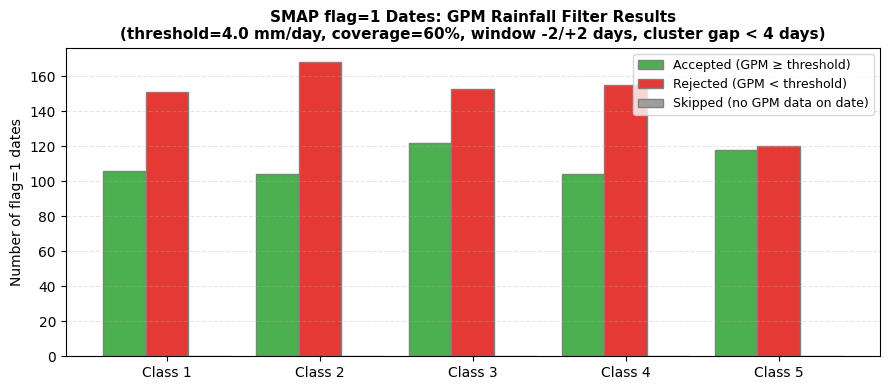

Plot displayed.


In [21]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print('=== Rainfall Filter Summary ===\n')
print(f'{"Class":<7} {"Input flag=1":>13} {"Accepted":>9} {"Rejected":>9} '
      f'{"No GPM":>8} {"Retention%":>11}')
print('-' * 60)

for cls in classes:
    n_in       = len(calib_flag1[cls])
    n_accepted = len(filtered_results[cls]['accepted_events'])
    n_rejected = len(filtered_results[cls]['rejected_dates'])
    n_no_gpm   = len(filtered_results[cls]['missing_gpm_dates'])
    pct        = 100 * n_accepted / n_in if n_in > 0 else 0
    print(f'{cls:<7} {n_in:>13} {n_accepted:>9} {n_rejected:>9} '
          f'{n_no_gpm:>8} {pct:>10.1f}%')

print()

# ── Bar chart: accepted vs rejected per class ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(classes))
w = 0.28
n_accepted_arr  = [len(filtered_results[c]['accepted_events'])   for c in classes]
n_rejected_arr  = [len(filtered_results[c]['rejected_dates'])    for c in classes]
n_nogpm_arr     = [len(filtered_results[c]['missing_gpm_dates']) for c in classes]

ax.bar(x - w,   n_accepted_arr, w, label='Accepted (GPM ≥ threshold)',   color='#4CAF50', edgecolor='grey')
ax.bar(x,       n_rejected_arr, w, label='Rejected (GPM < threshold)',    color='#E53935', edgecolor='grey')
ax.bar(x + w,   n_nogpm_arr,    w, label='Skipped (no GPM data on date)', color='#9E9E9E', edgecolor='grey')

ax.set_xticks(x)
ax.set_xticklabels([f'Class {c}' for c in classes], fontsize=10)
ax.set_ylabel('Number of flag=1 dates', fontsize=10)
_mode_str = (
    f'window -{DAYS_BEFORE}/+{DAYS_AFTER} days'
    if USE_WINDOW_CHECK else 'flag=1 day only'
)
ax.set_title(
    f'SMAP flag=1 Dates: GPM Rainfall Filter Results\n'
    f'(threshold={RAINFALL_THRESHOLD_MM} mm/day, coverage={STATION_COVERAGE_THRESHOLD:.0%}, '
    f'{_mode_str}, cluster gap < 4 days)',
    fontsize=11, fontweight='bold',
)
ax.legend(fontsize=9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
print('Plot displayed.')


In [22]:
# ── Quick peek at each output CSV ─────────────────────────────────────────────
for cls in classes:
    out_path = OUTPUT_DIR / f'class_{cls}_filtered_dates.csv'
    if not out_path.exists():
        print(f'Class {cls}: file not found (all dates may have been rejected).\n')
        continue
    tmp = pd.read_csv(out_path)
    print(f'── Class {cls}  ({len(tmp)} rows) ──────────────────────────────────────')
    print(tmp.head(10).to_string(index=False))
    print()


── Class 1  (463 rows) ──────────────────────────────────────
event_date       date  offset_days  flag
2015-04-08 2015-04-06           -2     0
2015-04-08 2015-04-07           -1     0
2015-04-08 2015-04-08            0     1
2015-04-08 2015-04-09            1     0
2015-04-08 2015-04-10            2     0
2015-05-10 2015-05-08           -2     0
2015-05-10 2015-05-09           -1     0
2015-05-10 2015-05-10            0     1
2015-05-10 2015-05-11            1     0
2015-05-10 2015-05-12            2     0

── Class 2  (451 rows) ──────────────────────────────────────
event_date       date  offset_days  flag
2015-04-08 2015-04-06           -2     0
2015-04-08 2015-04-07           -1     0
2015-04-08 2015-04-08            0     1
2015-04-08 2015-04-09            1     0
2015-04-08 2015-04-10            2     0
2015-04-16 2015-04-14           -2     0
2015-04-16 2015-04-15           -1     0
2015-04-16 2015-04-16            0     1
2015-04-16 2015-04-17            1     0
2015-04-16 201

## 10 · Removed (Rejected) Dates Detail

Dates that had `flag = 1` in the original calibration CSVs but were **rejected** by the GPM filter
(i.e. < 75 % of class stations received ≥ 5 mm rainfall) are listed here, along with the actual
mean GPM precipitation across the nearest-neighbour matched grid cells on that day, so the
rejection reason can be inspected.

Dates absent from the GPM archive entirely are also listed separately.


In [23]:
for cls in classes:
    rejected  = filtered_results[cls]['rejected_dates']
    missing   = filtered_results[cls]['missing_gpm_dates']
    accepted  = filtered_results[cls]['accepted_events']
    gpm_idx_list = class_gpm_indices[cls]
    n_stations   = len(gpm_idx_list)

    print(f'══ Class {cls} ══  '
          f'{len(accepted)} accepted | {len(rejected)} rejected | {len(missing)} no-GPM-data')

    if rejected:
        print(f'  Rejected dates (flag=1 but GPM < {RAINFALL_THRESHOLD_MM} mm/day '
              f'at ≥ {STATION_COVERAGE_THRESHOLD:.0%} of stations):')
        rows_rej = []
        for d in sorted(rejected):
            t_idx = gpm_date_index.get(d.date())
            precip_vals = np.array([
                float(gpm_precip[t_idx, li, ai])
                for li, ai in gpm_idx_list
            ]) if t_idx is not None else np.full(n_stations, np.nan)
            frac_wet  = float(np.sum(precip_vals >= RAINFALL_THRESHOLD_MM)) / n_stations
            mean_p    = float(np.nanmean(precip_vals))
            max_p     = float(np.nanmax(precip_vals))
            rows_rej.append({
                'date'           : d.strftime('%Y-%m-%d'),
                'mean_GPM_mm'    : round(mean_p, 2),
                'max_GPM_mm'     : round(max_p, 2),
                'frac_wet_stns'  : round(frac_wet, 3),
            })
        rej_df = pd.DataFrame(rows_rej)
        print(rej_df.to_string(index=False))

    if missing:
        print(f'  Dates with NO GPM record   : '
              f'{", ".join(d.strftime("%Y-%m-%d") for d in sorted(missing))}')

    print()


══ Class 1 ══  106 accepted | 151 rejected | 0 no-GPM-data
  Rejected dates (flag=1 but GPM < 4.0 mm/day at ≥ 60% of stations):
      date  mean_GPM_mm  max_GPM_mm  frac_wet_stns
2015-04-29         0.08        0.70          0.000
2015-05-15         0.53        2.03          0.000
2015-06-01         1.06        4.73          0.038
2015-06-14         1.66        9.74          0.154
2015-10-28         0.14        1.04          0.000
2015-12-07         0.00        0.00          0.000
2015-12-09         0.09        0.47          0.000
2015-12-10         0.00        0.00          0.000
2015-12-12         0.00        0.00          0.000
2015-12-18         0.00        0.00          0.000
2016-03-20         0.52        4.13          0.038
2016-05-04         0.04        0.21          0.000
2016-06-10         7.93       34.89          0.462
2016-06-11         1.20        3.08          0.000
2016-06-16         1.45        6.81          0.115
2016-12-04         0.00        0.00          0.000
2016-

## 11 · Load SMAP NetCDF for SM Visualisation

Load the SMAP L3 NetCDF to build the daily pivot table of soil-moisture per station.
This is the same preprocessing as in `SPL3SMP_E_calib_dates_per_class.ipynb` Section 3.


In [24]:

SM_SOURCE_VIS = 'BOTH'    # 'AM' | 'PM' | 'BOTH'
SMAP_FILL_VAL = -9999.0

if not SMAP_NC_FILE.exists():
    raise FileNotFoundError(f'SMAP NC file not found: {SMAP_NC_FILE}')

print(f'Opening: {SMAP_NC_FILE}')
_ds = nc.Dataset(SMAP_NC_FILE, 'r')
_epoch   = _dt(2000, 1, 1)
_time_dt = np.array([_epoch + _td(seconds=float(t)) for t in _ds.variables['time'][:]])
_lat     = _ds.variables['latitude'][:]
_lon     = _ds.variables['longitude'][:]
_sm_am   = _ds.variables['soil_moisture_am'][:]
_sm_pm   = _ds.variables['soil_moisture_pm'][:]
_ds.close()

_df = pd.DataFrame({
    'time': _time_dt, 'latitude': _lat, 'longitude': _lon,
    'soil_moisture_am': _sm_am, 'soil_moisture_pm': _sm_pm,
})
_df = _df[(_df['latitude'] != SMAP_FILL_VAL) & (_df['longitude'] != SMAP_FILL_VAL)]
_df = _df[(_df['soil_moisture_am'] != SMAP_FILL_VAL) | (_df['soil_moisture_pm'] != SMAP_FILL_VAL)]

if SM_SOURCE_VIS == 'AM':
    _df['sm'] = _df['soil_moisture_am'].replace(SMAP_FILL_VAL, np.nan)
elif SM_SOURCE_VIS == 'PM':
    _df['sm'] = _df['soil_moisture_pm'].replace(SMAP_FILL_VAL, np.nan)
else:
    _am = _df['soil_moisture_am'].replace(SMAP_FILL_VAL, np.nan)
    _pm = _df['soil_moisture_pm'].replace(SMAP_FILL_VAL, np.nan)
    _df['sm'] = np.nanmean([_am, _pm], axis=0)

_df = _df.dropna(subset=['sm'])

# String station keys using actual SMAP lat/lon
_df['station'] = (
    _df['latitude'].round(4).map(lambda x: f'{x:.4f}') + '_' +
    _df['longitude'].round(4).map(lambda x: f'{x:.4f}')
)
_df['date'] = pd.to_datetime(_df['time']).dt.normalize()

_daily = (
    _df.groupby(['station', 'date'], as_index=False)
       .agg(sm_mean=('sm', 'mean'))
)
ts_full_vis = _daily.pivot_table(index='date', columns='station', values='sm_mean')
ts_full_vis.columns.name = None
ts_full_vis = ts_full_vis.sort_index()

# ── Parse unique SMAP station coordinates from pivot column names ─────────────
# Column format: "lat_lon" where both are 4-decimal strings
smap_station_keys  = list(ts_full_vis.columns)
smap_station_coords = []     # (lat, lon) float pairs, parallel to smap_station_keys
for key in smap_station_keys:
    lat_s, lon_s = key.split('_')
    smap_station_coords.append((float(lat_s), float(lon_s)))
smap_station_coords = np.array(smap_station_coords)   # (n_smap_stns, 2)

# KDTree over SMAP (lat, lon) to nearest-match class_df points → correct pixel
smap_stn_tree = cKDTree(smap_station_coords)

def class_df_to_smap_keys(latlon_array):
    """Return SMAP station keys nearest to each (lat, lon) in latlon_array."""
    _, idx = smap_stn_tree.query(latlon_array)
    return [smap_station_keys[i] for i in idx]

# ── Build per-class SMAP station key lists ────────────────────────────────────
# Use nearest-neighbour matching so GPM-aligned class_df coords map correctly
# to actual SMAP pixel centres, not a direct string equality that fails on mismatch.
class_stations_vis = {}
for cls in classes:
    subset = class_df[class_df['rainfall_class'] == cls][['latitude', 'longitude']]
    matched_keys = class_df_to_smap_keys(subset.values)
    # Deduplicate while preserving order (multiple class_df rows may hit the same pixel)
    seen = set()
    unique_keys = [k for k in matched_keys if not (k in seen or seen.add(k))]
    class_stations_vis[cls] = unique_keys
    print(f'  Class {cls}: {len(subset)} class-CSV entries → '
          f'{len(unique_keys)} unique SMAP stations (NN-matched)')

print(f'\nSMAP pivot shape : {ts_full_vis.shape}')
print(f'Date range       : {ts_full_vis.index[0].date()}  →  {ts_full_vis.index[-1].date()}')
print(f'Total unique SMAP stations in pivot: {len(smap_station_keys)}')


Opening: G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc
  Class 1: 26 class-CSV entries → 16 unique SMAP stations (NN-matched)
  Class 2: 13 class-CSV entries → 12 unique SMAP stations (NN-matched)
  Class 3: 39 class-CSV entries → 33 unique SMAP stations (NN-matched)
  Class 4: 37 class-CSV entries → 32 unique SMAP stations (NN-matched)
  Class 5: 29 class-CSV entries → 29 unique SMAP stations (NN-matched)

SMAP pivot shape : (1869, 156)
Date range       : 2015-04-03  →  2025-12-31
Total unique SMAP stations in pivot: 156


## 12 · SM Temporal Variation with Filtered Windows – Per Class

Mirrors the Section 10 plot in `SPL3SMP_E_calib_dates_per_class.ipynb`.

* **Green shaded band** – ±`DATE_WINDOW` day window around each GPM-validated event date (written to the filtered CSV)
* **Red dashed line** – GPM-accepted `flag = 1` date
* **Grey dashed line** – Rejected `flag = 1` date (SMAP SM increased but GPM rainfall was insufficient)

Set `PLOT_START` / `PLOT_STOP` to zoom into any sub-period.


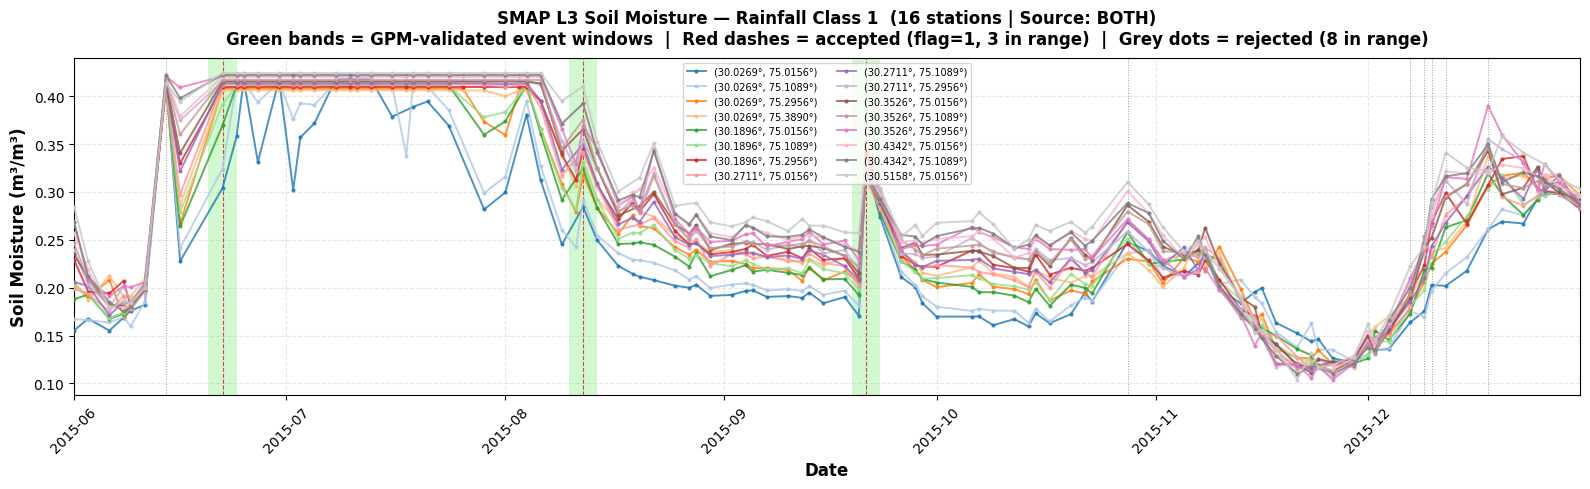

Class 1: 106 accepted | 151 rejected | plotted 2015-06-01 → 2015-12-31



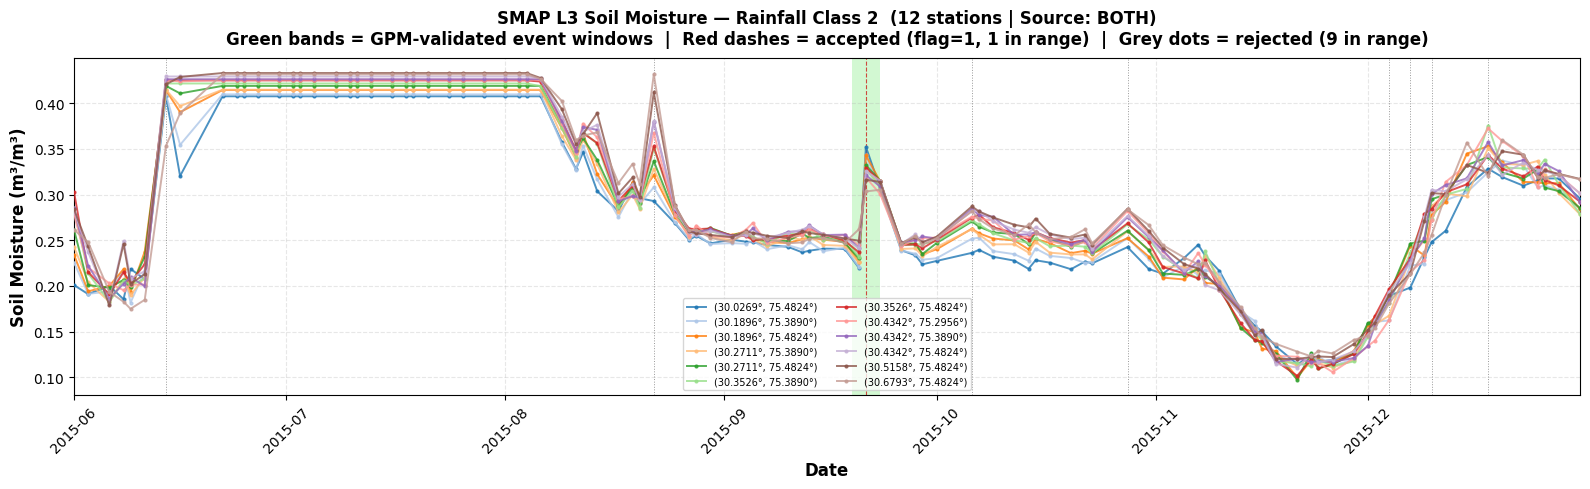

Class 2: 104 accepted | 168 rejected | plotted 2015-06-01 → 2015-12-31

  Class 3: station legend omitted (33 stations).


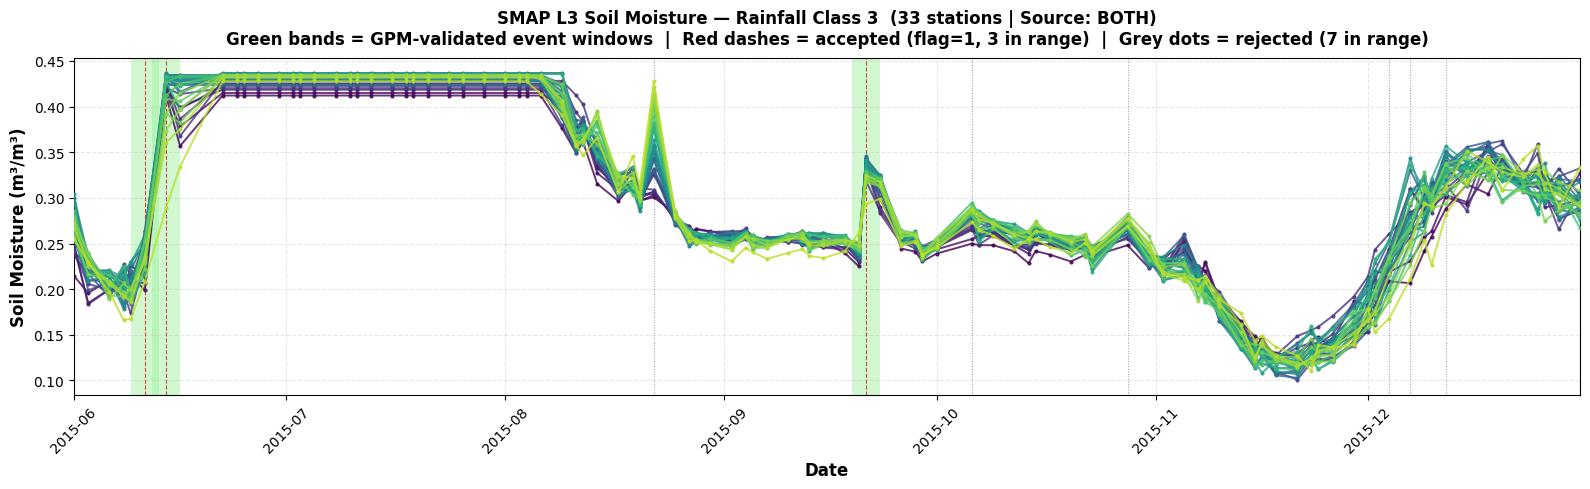

Class 3: 122 accepted | 153 rejected | plotted 2015-06-01 → 2015-12-31

  Class 4: station legend omitted (32 stations).


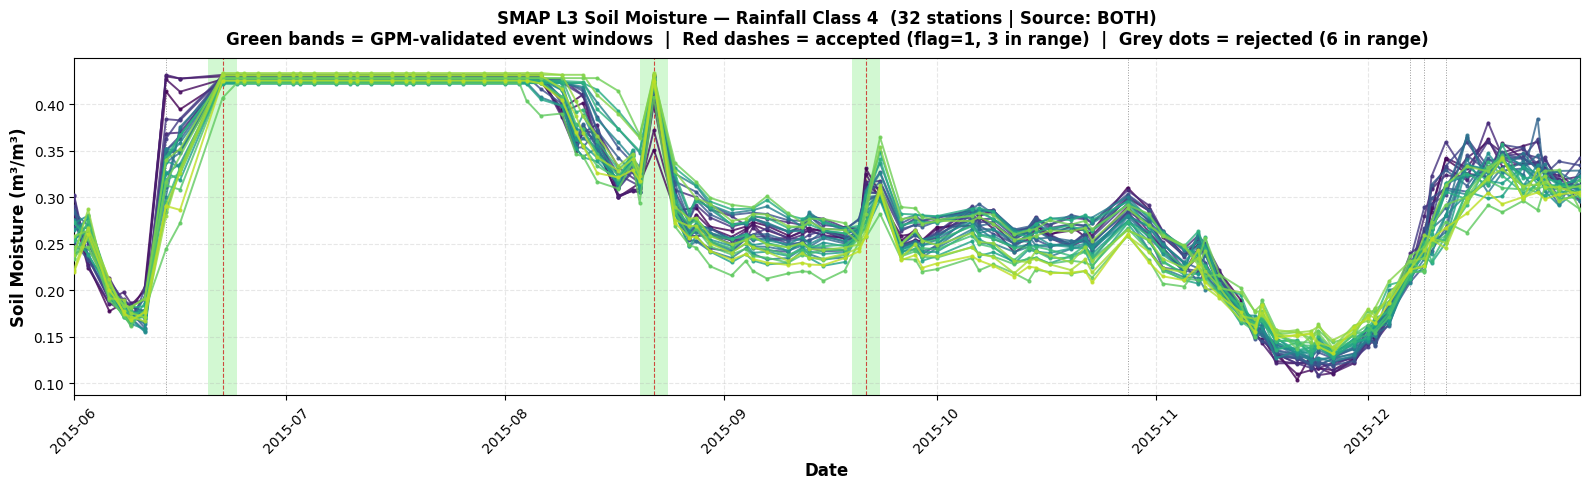

Class 4: 104 accepted | 155 rejected | plotted 2015-06-01 → 2015-12-31

  Class 5: station legend omitted (29 stations).


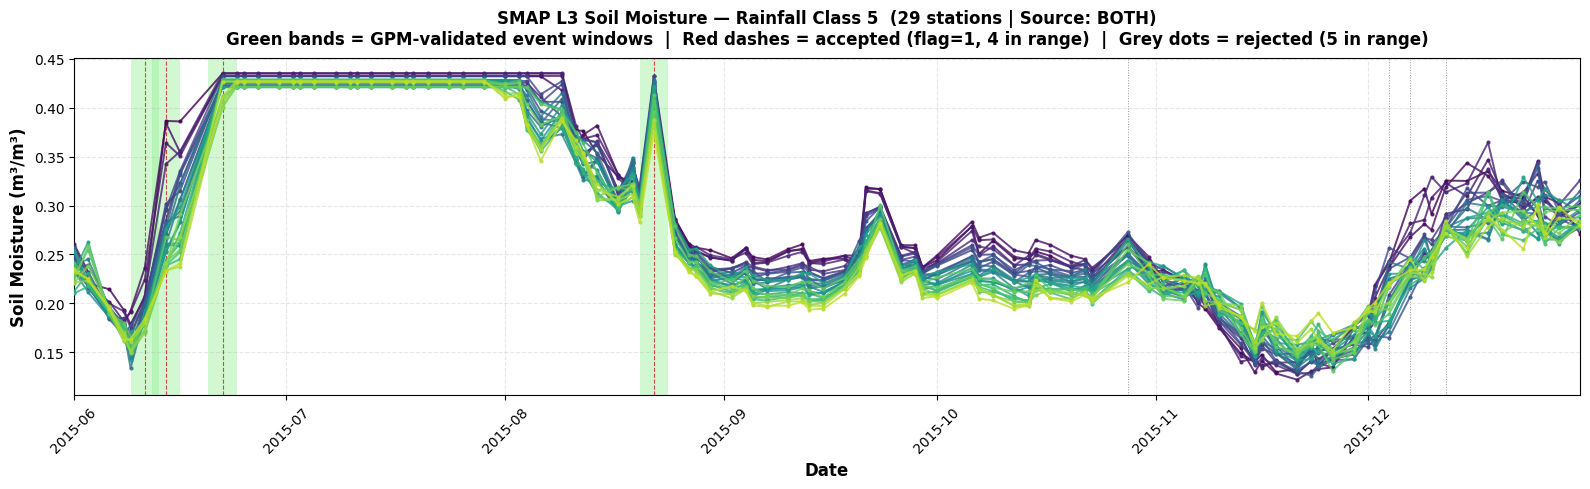

Class 5: 118 accepted | 120 rejected | plotted 2015-06-01 → 2015-12-31



In [27]:
# ── Date range to visualise ───────────────────────────────────────────────────
# PLOT_START = '2015-01-01'   # change to zoom into any period
# PLOT_STOP  = '2015-05-31'

PLOT_START = '2015-06-01'   # change to zoom into any period
PLOT_STOP  = '2015-12-31'
# ─────────────────────────────────────────────────────────────────────────────
plot_start = pd.Timestamp(PLOT_START)
plot_stop  = pd.Timestamp(PLOT_STOP)

def _station_colors(n):
    if n <= 10:
        return plt.cm.tab10(np.linspace(0, 1, 10))
    if n <= 20:
        return plt.cm.tab20(np.linspace(0, 1, 20))
    return plt.cm.viridis(np.linspace(0, 0.9, n))

for cls in classes:
    stations_in_class = class_stations_vis.get(cls, [])
    if not stations_in_class:
        print(f'Class {cls}: no matched SMAP stations – skipping plot.')
        continue

    # ── Slice SMAP pivot to this class and date range ─────────────────────────
    ts_cls = ts_full_vis[stations_in_class].dropna(how='all')
    ts_cls = ts_cls[(ts_cls.index >= plot_start) & (ts_cls.index <= plot_stop)]

    if ts_cls.empty:
        print(f'Class {cls}: no SMAP data in [{PLOT_START}, {PLOT_STOP}] – skipping.')
        continue

    # ── Long-format for plotting ──────────────────────────────────────────────
    long_rows = []
    for stn_key in stations_in_class:
        if stn_key not in ts_cls.columns:
            continue
        s = ts_cls[stn_key].dropna().reset_index()
        s.columns = ['date', 'sm_mean']
        s['station'] = stn_key
        long_rows.append(s)

    if not long_rows:
        print(f'Class {cls}: no valid SM data in range – skipping.')
        continue

    ts_long = pd.concat(long_rows, ignore_index=True)

    # ── Accepted and rejected dates from filtered_results ─────────────────────
    accepted_set  = set(filtered_results[cls]['accepted_events'])
    rejected_set  = set(filtered_results[cls]['rejected_dates'])

    # ── Accepted event windows (spans stored in 'rows') ───────────────────────
    # Reconstruct per-event spans: [event_date - DAYS_BEFORE … event_date + DAYS_AFTER]
    accepted_sorted = sorted(accepted_set)

    colors_arr = _station_colors(len(stations_in_class))
    fig, ax = plt.subplots(figsize=(16, 5))

    # ── 1 · Green bands for accepted event windows ────────────────────────────
    for ev in accepted_sorted:
        win_start = max(ev - pd.Timedelta(days=DAYS_BEFORE), plot_start)
        win_end   = min(ev + pd.Timedelta(days=DAYS_AFTER),  plot_stop)
        if win_start <= win_end:
            ax.axvspan(win_start, win_end,
                       color='#90EE90', alpha=0.40, linewidth=0, zorder=1)

    # ── 2 · Red dashed lines – GPM-accepted flag=1 dates ─────────────────────
    for d in sorted(accepted_set):
        if plot_start <= d <= plot_stop:
            ax.axvline(d, color='#CC0000', linewidth=0.8,
                       linestyle='--', alpha=0.7, zorder=2,
                       label='Accepted (GPM ✓)' if d == sorted(accepted_set)[0] else '')

    # ── 3 · Grey dashed lines – rejected flag=1 dates ────────────────────────
    for d in sorted(rejected_set):
        if plot_start <= d <= plot_stop:
            ax.axvline(d, color='#555555', linewidth=0.7,
                       linestyle=':', alpha=0.6, zorder=2,
                       label='Rejected (GPM ✗)' if d == sorted(rejected_set)[0] else '')

    # ── 4 · Per-station SM time series ───────────────────────────────────────
    for idx, stn_key in enumerate(stations_in_class):
        stn_data = ts_long[ts_long['station'] == stn_key].sort_values('date')
        if stn_data.empty:
            continue
        lat_part, lon_part = stn_key.split('_')
        ax.plot(
            stn_data['date'], stn_data['sm_mean'],
            marker='o', markersize=2, linewidth=1.4, alpha=0.80,
            color=colors_arr[idx % len(colors_arr)],
            label=f'({lat_part}°, {lon_part}°)',
            zorder=3,
        )

    # ── 5 · Formatting ────────────────────────────────────────────────────────
    ax.set_xlim(plot_start, plot_stop)
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Soil Moisture (m³/m³)', fontsize=12, fontweight='bold')

    n_acc = len([d for d in accepted_set if plot_start <= d <= plot_stop])
    n_rej = len([d for d in rejected_set  if plot_start <= d <= plot_stop])
    ax.set_title(
        f'SMAP L3 Soil Moisture — Rainfall Class {cls}  '
        f'({len(stations_in_class)} stations | Source: {SM_SOURCE_VIS})\n'
        f'Green bands = GPM-validated event windows  |  '
        f'Red dashes = accepted (flag=1, {n_acc} in range)  |  '
        f'Grey dots = rejected ({n_rej} in range)',
        fontsize=12, fontweight='bold', pad=10,
    )
    ax.grid(True, alpha=0.3, linestyle='--', zorder=0)
    ax.tick_params(axis='x', rotation=45)

    # Deduplicated legend: station lines + one entry each for accepted/rejected
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if len(stations_in_class) <= 18:
        ax.legend(by_label.values(), by_label.keys(),
                  fontsize=7, loc='best', ncol=2, framealpha=0.8)
    else:
        print(f'  Class {cls}: station legend omitted ({len(stations_in_class)} stations).')
        # Still show accepted/rejected legend entries
        acc_rej = {k: v for k, v in by_label.items()
                   if 'Accepted' in k or 'Rejected' in k}
        if acc_rej:
            ax.legend(acc_rej.values(), acc_rej.keys(), fontsize=9, loc='upper right')

    plt.tight_layout()
    plt.show()
    print(f'Class {cls}: {len(accepted_set)} accepted | '
          f'{len(rejected_set)} rejected | '
          f'plotted {PLOT_START} → {PLOT_STOP}\n')
